In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_excel(r"C:\Users\mi compu\Documents\Visual studio\Interlub_hackaton\DataHackathon.xlsx")

In [ ]:
# Filtrar todas las variables que contienen 'Temp' o 'Temperature' en su nombre
temp_keywords = ["Temp", "Temperature", "PreformTemperatureControl"]
df_temp = df[df['variable'].str.contains('|'.join(temp_keywords), case=False, na=False)]

# Incluir también la variable de producción de botellas
df_prod = df[df['variable'] == "CONTIFORM_MMA.CONTIFORM_MMA1.WS_Tot_Bottles.0"]

# Renombrar la variable de producción de botellas
df_prod = df_prod.copy()
df_prod.loc[:, 'variable'] = "produccion_botellas"

# Unir ambas selecciones
df_filtered = pd.concat([df_temp, df_prod])

# Convertir la columna 'time' a formato datetime manejando formatos mixtos
df_filtered['time'] = pd.to_datetime(df_filtered['time'], errors='coerce', format='mixed')
df_filtered = df_filtered.dropna(subset=['time'])

# Convertir la columna 'value' a numérica, forzando errores a NaN
df_filtered['value'] = pd.to_numeric(df_filtered['value'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['value'])

# Verificar cuántas variables de temperatura se encontraron
print("Variables de temperatura seleccionadas:")
print(df_temp['variable'].unique())

# Filtrar solo variables de temperatura, excluyendo producción de botellas
df_temp_only = df_filtered[df_filtered['variable'] != "produccion_botellas"]

# Verificar si hay variables de temperatura para graficar
unique_variables = df_temp_only['variable'].unique()
num_vars = len(unique_variables)

In [ ]:
# Graficar las variables de temperatura en series de tiempo. Mostrar el comportamiento de su valor a través del tiempo
if num_vars == 0:
    print("No se encontraron variables de temperatura para graficar.")
else:
    fig, axes = plt.subplots(nrows=num_vars, ncols=1, figsize=(12, 3 * num_vars), sharex=True)

    if num_vars == 1:
        axes = [axes]

    for ax, variable in zip(axes, unique_variables):
        data = df_temp_only[df_temp_only['variable'] == variable]
        ax.plot(data['time'], data['value'], label=variable)
        ax.set_title(variable)
        ax.set_ylabel('Valor')
        ax.legend()
        ax.grid()

    plt.xlabel('Tiempo')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

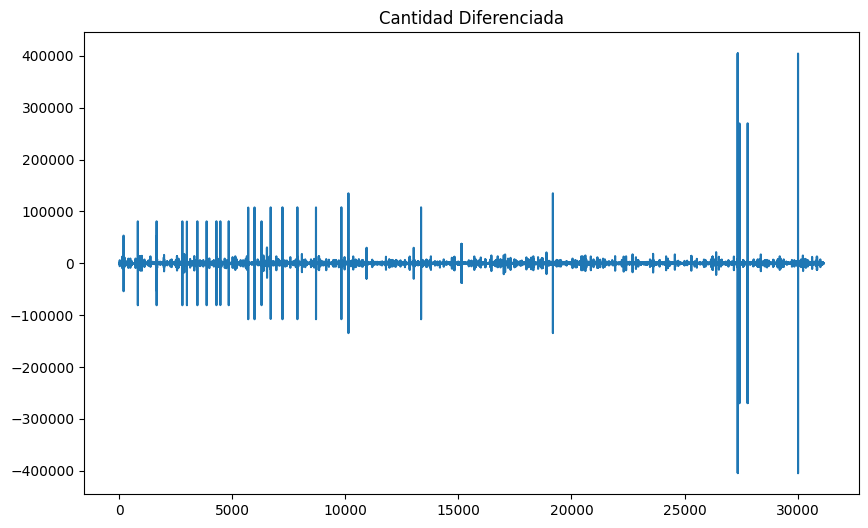

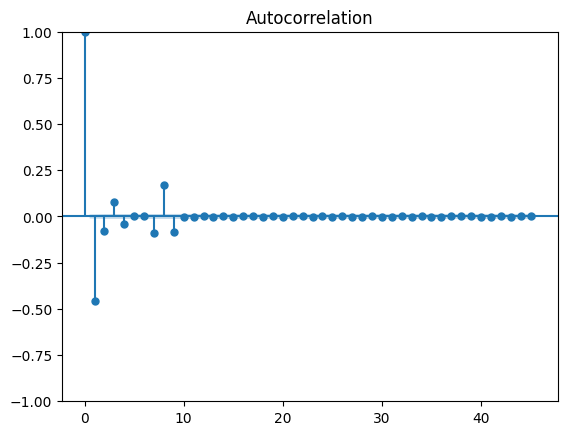

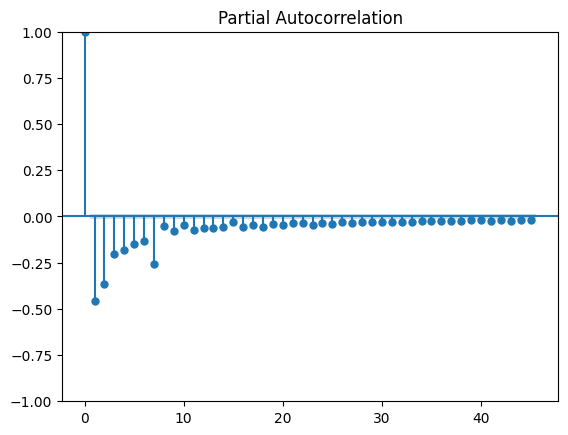

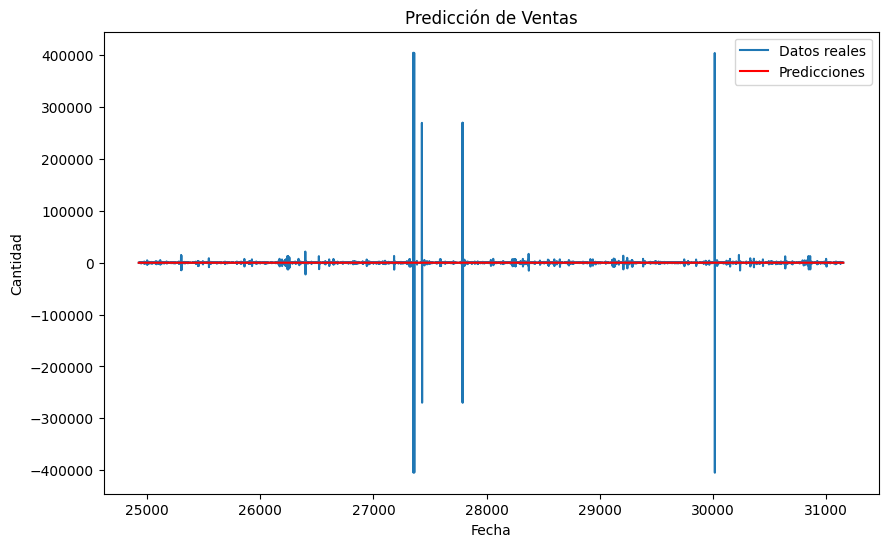

In [22]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Asegurarte de que tus datos están en formato adecuado
df['Creacion Orden de Venta'] = pd.to_datetime(df['Creacion Orden de Venta'])
df['Cantidad'] = pd.to_numeric(df['Cantidad'], errors='coerce')

# Diferenciación para hacer que los datos sean estacionarios
df['Cantidad_diff'] = df['Cantidad'].diff().dropna()

# Visualiza la serie de tiempo diferenciada para asegurarte de que se vea más estable
plt.figure(figsize=(10, 6))
plt.plot(df['Cantidad_diff'])
plt.title('Cantidad Diferenciada')
plt.show()

# Si los datos aún no son estacionarios, puedes realizar más diferencias
# df['Cantidad_diff'] = df['Cantidad_diff'].diff().dropna()

# Revisa el gráfico de autocorrelación (ACF) y autocorrelación parcial (PACF) para elegir p y q
plot_acf(df['Cantidad_diff'].dropna())
plot_pacf(df['Cantidad_diff'].dropna())
plt.show()

# Divide los datos en conjunto de entrenamiento y prueba
train_size = int(len(df) * 0.8)
train, test = df['Cantidad_diff'][:train_size], df['Cantidad_diff'][train_size:]

# Ajustar el modelo ARIMA (usando el valor de p, d, q según el análisis ACF/PACF)
model = ARIMA(train, order=(5, 1, 0))  # Puedes ajustar los parámetros (p, d, q) según el gráfico ACF/PACF
model_fit = model.fit()

# Hacer predicciones sobre el conjunto de prueba
predictions = model_fit.forecast(steps=len(test))

# Visualizar las predicciones
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Datos reales')
plt.plot(test.index, predictions, label='Predicciones', color='red')
plt.title('Predicción de Ventas')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.legend()
plt.show()


In [23]:
df.head()

,Orden de Venta,Creacion Orden de Venta,Codigo Cliente,Articulo,Cantidad,Unidad de venta,Cantidad_diff
0,ABC063830,2021-01-04,F26E901B,IVP11576,60,L,NaN
1,ABC063832,2021-01-04,12558C43,IVP07229,540,KG,480.0
2,ABC063833,2021-01-04,A760F354,IVP04039,3,PZA,-537.0
3,ABC063834,2021-01-04,A760F354,IVP04039,4,PZA,1.0
4,ABC063835,2021-01-04,A760F354,IVP01010,1,PZA,-3.0


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import numpy as np

# Cargar los datos (asegúrate de que 'Creacion Orden de Venta' es tipo datetime y 'Cantidad' existe)
df = pd.read_excel(r"C:\Users\mi compu\Documents\Visual studio\Interlub_hackaton\DataHackathon.xlsx", 
                   parse_dates=['Creacion Orden de Venta'], index_col='Creacion Orden de Venta')

# Verifica que las columnas están correctamente cargadas
print(df.columns)

# Seleccionar la columna de interés (por ejemplo 'Cantidad')
series = df['Cantidad']

# Verifica si la serie temporal es estacionaria (prueba de Dickey-Fuller)
result = adfuller(series.dropna())
print(f'Estadístico de prueba ADF: {result[0]}')
print(f'Valor p: {result[1]}')

# Si el valor p es mayor que 0.05, la serie no es estacionaria y necesita diferenciación
if result[1] > 0.05:
    print("La serie no es estacionaria, aplicando diferenciación")
    series_diff = series.diff().dropna()
else:
    print("La serie es estacionaria")

Index(['Orden de Venta', 'Codigo Cliente', 'Articulo', 'Cantidad',
       'Unidad de venta'],
      dtype='object')
Estadístico de prueba ADF: -41.54172527875384
Valor p: 0.0
La serie es estacionaria


In [31]:
series_diff = series.diff().dropna()

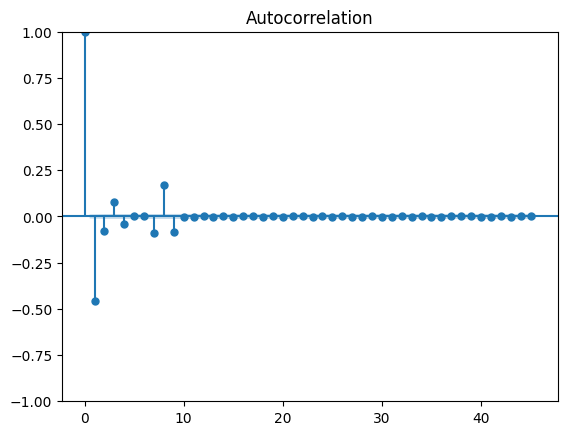

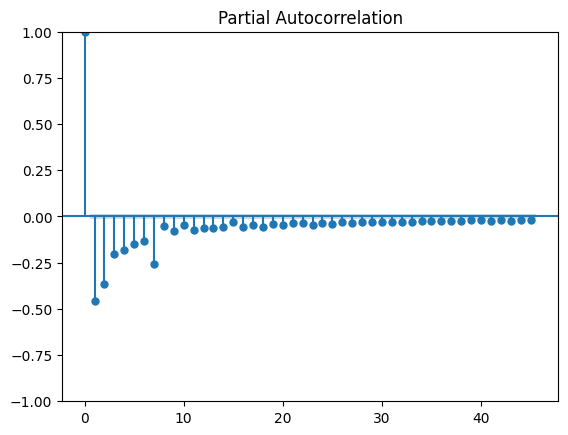

In [32]:
# Graficar ACF y PACF para decidir p y q
plot_acf(series_diff)
plot_pacf(series_diff)
plt.show()

c:\Users\mi compu\Documents\Visual studio\Interlub_hackaton\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mi compu\Documents\Visual studio\Interlub_hackaton\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mi compu\Documents\Visual studio\Interlub_hackaton\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:               Cantidad   No. Observations:                31156
Model:                 ARIMA(1, 1, 1)   Log Likelihood             -314068.096
Date:                Thu, 20 Mar 2025   AIC                         628142.192
Time:                        17:34:36   BIC                         628167.232
Sample:                             0   HQIC                        628150.212
                              - 31156                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0899      0.000    191.889      0.000       0.089       0.091
ma.L1         -1.0000      0.000  -4694.640      0.000      -1.000      -1.000
sigma2      3.338e+07    6.4e-12   5.22e+18      0.0

c:\Users\mi compu\Documents\Visual studio\Interlub_hackaton\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\mi compu\Documents\Visual studio\Interlub_hackaton\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


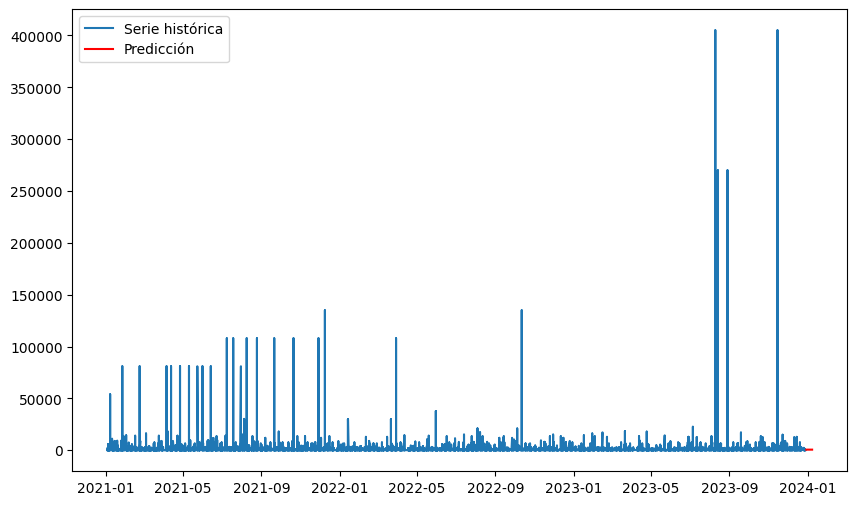

In [33]:
# Ajustar el modelo ARIMA (p, d, q) - Ajusta los valores de p, d y q según tus gráficas ACF/PACF
p = 1  # Orden AR
d = 1  # Diferenciación
q = 1  # Orden MA

# Entrenar el modelo ARIMA
model = ARIMA(series, order=(p, d, q))
model_fit = model.fit()

# Imprimir resumen del modelo
print(model_fit.summary())

# Hacer predicciones (por ejemplo, los próximos 10 días)
forecast_steps = 10
forecast = model_fit.forecast(steps=forecast_steps)

# Mostrar las predicciones
print("Predicciones:")
print(forecast)

# Graficar los resultados
plt.figure(figsize=(10,6))
plt.plot(series, label='Serie histórica')

# Crear un rango de fechas para la predicción
forecast_dates = pd.date_range(series.index[-1], periods=forecast_steps + 1, freq='D')[1:]

# Graficar las predicciones
plt.plot(forecast_dates, forecast, label='Predicción', color='red')
plt.legend()
plt.show()


In [28]:
# Cargar el archivo sin especificar el índice para ver todas las columnas
df = pd.read_excel(r"C:\Users\mi compu\Documents\Visual studio\Interlub_hackaton\DataHackathon.xlsx")

# Ver las primeras filas y las columnas
print(df.columns)
print(df.head())



Index(['Orden de Venta', 'Creacion Orden de Venta', 'Codigo Cliente',
       'Articulo', 'Cantidad', 'Unidad de venta'],
      dtype='object')
  Orden de Venta Creacion Orden de Venta Codigo Cliente  Articulo  Cantidad  \
0      ABC063830              2021-01-04       F26E901B  IVP11576        60   
1      ABC063832              2021-01-04       12558C43  IVP07229       540   
2      ABC063833              2021-01-04       A760F354  IVP04039         3   
3      ABC063834              2021-01-04       A760F354  IVP04039         4   
4      ABC063835              2021-01-04       A760F354  IVP01010         1   

  Unidad de venta  
0               L  
1              KG  
2             PZA  
3             PZA  
4             PZA  


In [34]:
df_arima = df.groupby('Creacion Orden de Venta')['Cantidad'].sum()
df_arima = df_arima.asfreq('D')  # Rellenar con frecuencia diaria
df_arima = df_arima.fillna(0)  # Rellenar valores faltantes con 0


In [35]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_arima)
print(f"Valor p: {result[1]}")

if result[1] > 0.05:
    print("La serie no es estacionaria, aplicando diferenciación")
    df_arima = df_arima.diff().dropna()


Valor p: 8.58991794637291e-07


In [36]:
from statsmodels.tsa.arima.model import ARIMA

p, d, q = 1, 1, 1  # Ajustar según ACF/PACF
model = ARIMA(df_arima, order=(p, d, q))
model_fit = model.fit()

# Predicción
forecast = model_fit.forecast(steps=10)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# 📌 Cargar datos
df = pd.read_excel(r"C:\Users\mi compu\Documents\Visual studio\Interlub_hackaton\DataHackathon.xlsx", 
                   parse_dates=['Creacion Orden de Venta'], index_col='Creacion Orden de Venta')

# 📌 Seleccionar la serie temporal
df_arima = df['Cantidad'].asfreq('D').fillna(method='ffill')  # Rellena valores faltantes

# 📌 Descomposición para ver la estacionalidad
decomp = seasonal_decompose(df_arima, model='additive', period=7)  # Ajusta el periodo si es necesario
decomp.plot()
plt.show()

# 📌 Ajustar ARIMA automáticamente con auto_arima
model_auto = pm.auto_arima(df_arima, seasonal=True, m=7, trace=True, suppress_warnings=True)
p, d, q, P, D, Q, S = model_auto.order + model_auto.seasonal_order
print(f"Mejor modelo SARIMA: ({p},{d},{q}) x ({P},{D},{Q},{S})")

# 📌 Ajustar modelo SARIMA con los mejores parámetros
model = SARIMAX(df_arima, order=(p, d, q), seasonal_order=(P, D, Q, S))
model_fit = model.fit()

# 📌 Hacer predicción de 30 días
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)

# 📌 Graficar resultados
plt.figure(figsize=(12,6))
plt.plot(df_arima, label='Datos Históricos')
plt.plot(pd.date_range(df_arima.index[-1], periods=forecast_steps + 1, freq='D')[1:], forecast, label='Predicción', color='red')
plt.legend()
plt.title("Predicción de Demanda con SARIMA")
plt.show()

# 📌 Si SARIMA no funciona bien, probar Prophet
if model_fit.aic > 1000:  # Condición de ejemplo, ajusta según necesites
    print("SARIMA no se ajusta bien, probando Prophet...")
    
    # Convertir datos a formato Prophet
    df_prophet = df_arima.reset_index()
    df_prophet.columns = ['ds', 'y']

    # Ajustar y predecir con Prophet
    model_prophet = Prophet()
    model_prophet.fit(df_prophet)

    future = model_prophet.make_future_dataframe(periods=30)
    forecast_prophet = model_prophet.predict(future)

    # Graficar Prophet
    model_prophet.plot(forecast_prophet)
    plt.show()


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject